# 📊 Notebook 04 — Dados Reais MapBiomas (2024)
**Projeto:** Sinop Agro-GIS · **Autor:** Jakson Pascoal | github.com/Jk-Pascoal  
**Fonte:** MapBiomas Collection 10.1 — `coverage_by_class_2024.csv`

In [1]:
import warnings; warnings.filterwarnings('ignore')
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

ROOT     = Path('..').resolve()
DATA_DIR = ROOT / 'data'
MAPS_DIR = ROOT / 'maps' / 'exportados'

BG = '#0a0a0f'
print('✅ OK')

✅ OK


## 1. Carregar CSV real do MapBiomas

In [2]:
df = pd.read_csv(DATA_DIR / 'uso_solo_mapbiomas' / 'coverage_by_class_2024.csv')

# Helper seguro para buscar valor
def get_ha(l1='', l2='', l3='', l4=''):
    mask = pd.Series([True] * len(df))
    if l1: mask &= (df['Level 1'] == l1)
    if l2: mask &= (df['Level 2'] == l2)
    if l3: mask &= (df['Level 3'] == l3)
    if l4: mask &= (df['Level 4'] == l4)
    result = df[mask]['2024']
    return result.iloc[0] if len(result) > 0 else 0.0

print('Estrutura do CSV:')
print(df[df['2024'] > 0].to_string(index=False))

Estrutura do CSV:
                          Level 1                   Level 2        Level 3               Level 4          2024
                           Forest                       NaN            NaN                   NaN 144652.293851
                           Forest          Forest Formation            NaN                   NaN 129179.006265
                           Forest          Floodable Forest            NaN                   NaN  15470.660296
                           Forest         Savanna Formation            NaN                   NaN      2.627290
Herbaceous and Shrubby Vegetation                       NaN            NaN                   NaN   1337.574709
Herbaceous and Shrubby Vegetation       Grassland Formation            NaN                   NaN     31.078576
Herbaceous and Shrubby Vegetation                   Wetland            NaN                   NaN   1306.496133
                          Farming                       NaN            NaN                   N

## 2. Métricas principais

In [3]:
# Extraindo valores com a estrutura exata do CSV
# Level 1 only (categorias agregadas — Level 2,3,4 = '')
floresta  = get_ha(l1='Forest')
farming   = get_ha(l1='Farming')
nao_veg   = get_ha(l1='Non vegetated area')
agua      = get_ha(l1='Water and Marine Environment')
herb      = get_ha(l1='Herbaceous and Shrubby Vegetation')
TOTAL     = floresta + farming + nao_veg + agua + herb

# Classes detalhadas
fl_nativa = get_ha(l2='Forest Formation')          # Forest > Forest Formation
fl_aluvial= get_ha(l2='Floodable Forest')          # Forest > Floodable Forest
soja      = get_ha(l4='Soybean')                   # Farming > Agriculture > Temp > Soybean
algodao   = get_ha(l4='Cotton')                    # Farming > Agriculture > Temp > Cotton
outras_lav= get_ha(l4='Other Temporary Crops')     # Farming > Agriculture > Temp > Other
pastagem  = get_ha(l2='Pasture')                   # Farming > Pasture
plantio   = get_ha(l2='Forest Plantation')         # Farming > Forest Plantation
urbano    = get_ha(l2='Urban Area')                # Non vegetated area > Urban Area
outras_nv = get_ha(l2='Other non Vegetated Areas') # Non vegetated area > Other
rios      = get_ha(l2='River, Lake and Ocean')     # Water > River, Lake and Ocean
area_umida= get_ha(l2='Wetland')                   # Herb > Wetland

print('=' * 58)
print('🌍 SINOP-MT — MapBiomas Collection 10.1 — Ano 2024')
print('=' * 58)
print(f'  Área total:          {TOTAL:>12,.0f} ha')
print(f'  🌿 Floresta:         {floresta:>12,.0f} ha  ({floresta/TOTAL*100:.1f}%)')
print(f'     Floresta Nativa:  {fl_nativa:>12,.0f} ha  ({fl_nativa/TOTAL*100:.1f}%)')
print(f'     Floresta Aluvial: {fl_aluvial:>12,.0f} ha  ({fl_aluvial/TOTAL*100:.1f}%)')
print(f'  🌾 Agropecuária:     {farming:>12,.0f} ha  ({farming/TOTAL*100:.1f}%)')
print(f'     Soja:             {soja:>12,.0f} ha  ({soja/TOTAL*100:.1f}%)')
print(f'     Pastagem:         {pastagem:>12,.0f} ha  ({pastagem/TOTAL*100:.1f}%)')
print(f'     Outras Lavouras:  {outras_lav:>12,.0f} ha  ({outras_lav/TOTAL*100:.1f}%)')
print(f'  💧 Água:             {agua:>12,.0f} ha  ({agua/TOTAL*100:.1f}%)')
print(f'  🏙️  Área Urbana:      {urbano:>12,.0f} ha  ({urbano/TOTAL*100:.1f}%)')
print('=' * 58)
print(f'\n🔍 INSIGHTS:')
print(f'  Soja/Floresta: {soja/floresta:.2f}x — cada 1 ha de floresta = {soja/floresta:.1f} ha de soja')
print(f'  Soja sozinha ocupa {soja/TOTAL*100:.1f}% do município')
print(f'  Área urbana = {urbano/TOTAL*100:.1f}% — menos que rios e lagos ({agua/TOTAL*100:.1f}%)')

🌍 SINOP-MT — MapBiomas Collection 10.1 — Ano 2024
  Área total:               399,086 ha
  🌿 Floresta:              144,652 ha  (36.2%)
     Floresta Nativa:       129,179 ha  (32.4%)
     Floresta Aluvial:       15,471 ha  (3.9%)
  🌾 Agropecuária:          229,137 ha  (57.4%)
     Soja:                  169,852 ha  (42.6%)
     Pastagem:               30,132 ha  (7.6%)
     Outras Lavouras:        28,619 ha  (7.2%)
  💧 Água:                   13,386 ha  (3.4%)
  🏙️  Área Urbana:             8,938 ha  (2.2%)

🔍 INSIGHTS:
  Soja/Floresta: 1.17x — cada 1 ha de floresta = 1.2 ha de soja
  Soja sozinha ocupa 42.6% do município
  Área urbana = 2.2% — menos que rios e lagos (3.4%)


## 3. Gráfico — Barras com dados reais

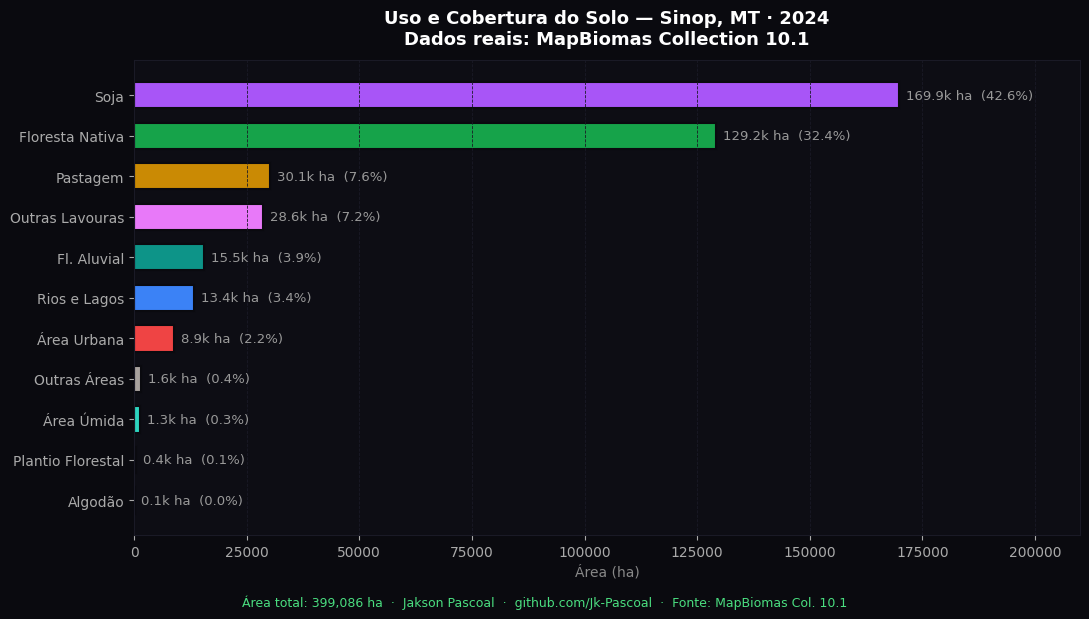

✅ PNG salvo: 08_barras_dados_reais_2024.png  (115 KB)


In [4]:
classes = [
    ('Soja',             soja,       '#a855f7'),
    ('Floresta Nativa',  fl_nativa,  '#16a34a'),
    ('Pastagem',         pastagem,   '#ca8a04'),
    ('Outras Lavouras',  outras_lav, '#e879f9'),
    ('Fl. Aluvial',      fl_aluvial, '#0d9488'),
    ('Rios e Lagos',     rios,       '#3b82f6'),
    ('Área Urbana',      urbano,     '#ef4444'),
    ('Área Úmida',       area_umida, '#2dd4bf'),
    ('Outras Áreas',     outras_nv,  '#a8a29e'),
    ('Plantio Florestal',plantio,    '#78716c'),
    ('Algodão',          algodao,    '#d8b4fe'),
]
classes.sort(key=lambda x: x[1], reverse=True)

labels = [c[0] for c in classes]
values = [c[1] for c in classes]
colors = [c[2] for c in classes]

fig, ax = plt.subplots(figsize=(11, 6), facecolor=BG)
ax.set_facecolor('#0d0d14')

bars = ax.barh(labels, values, color=colors, edgecolor=BG, linewidth=1.5, height=0.65)

for bar, val in zip(bars, values):
    if val > 0:
        ax.text(bar.get_width() + 1500, bar.get_y() + bar.get_height()/2,
                f'{val/1000:.1f}k ha  ({val/TOTAL*100:.1f}%)',
                va='center', color='#999', fontsize=9.5)

ax.set_title('Uso e Cobertura do Solo — Sinop, MT · 2024\n'
             'Dados reais: MapBiomas Collection 10.1',
             color='#fff', fontsize=13, fontweight='bold', pad=12)
ax.set_xlabel('Área (ha)', color='#888', fontsize=10)
ax.invert_yaxis()
ax.tick_params(colors='#aaa')
ax.grid(axis='x', color='#1a1a26', linewidth=0.6, linestyle='--')
for spine in ax.spines.values():
    spine.set_edgecolor('#1a1a26')
ax.set_xlim(0, 210_000)

plt.figtext(0.5, -0.02,
    f'Área total: {TOTAL:,.0f} ha  ·  Jakson Pascoal  ·  '
    'github.com/Jk-Pascoal  ·  Fonte: MapBiomas Col. 10.1',
    ha='center', color='#4ade80', fontsize=9)
plt.tight_layout()

out = MAPS_DIR / '08_barras_dados_reais_2024.png'
plt.savefig(str(out), dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()
print(f'✅ PNG salvo: {out.name}  ({out.stat().st_size/1024:.0f} KB)')

---
## ✅ Resumo — Notebook 04

| Etapa | Status |
|---|---|
| CSV MapBiomas real carregado | ✅ |
| Helper de busca seguro (sem IndexError) | ✅ |
| Insights com dados reais | ✅ |
| PNG `08_barras_dados_reais_2024.png` | ✅ |
| Série histórica 2000–2024 | ⏳ Baixar arquivo com todos os anos |

**Próximo:** Download do histórico completo → atualizar notebook 03 com dados reais.